In [1]:
import shap
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('../results/shap', exist_ok=True)

# Load data
X_train = pd.read_csv('../data/X_train.csv')
X_test  = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/y_test.csv').squeeze()

feature_names = X_test.columns.tolist()

# Sample 3000 rows for speed
X_shap_sample = X_test.sample(3000, random_state=42)
y_shap_sample = y_test.loc[X_shap_sample.index]

print(f"Data loaded: {X_shap_sample.shape}")
print(f"SHAP folder ready")
print(f"Models available: {os.listdir('../results/models/')}")

Data loaded: (3000, 30)
SHAP folder ready
Models available: ['hier_stage1_DT.pkl', 'hier_stage1_ET.pkl', 'hier_stage2_HGB.pkl', 'hier_stage1_LGBM.pkl', 'hier_stage2_RF.pkl', 'hier_stage1_HGB.pkl', 'hier_stage2_LGBM.pkl', 'hier_stage2_ET.pkl', 'hier_stage2_XGB.pkl', 'hier_stage2_DT.pkl', 'hier_stage1_RF.pkl', 'hier_stage1_XGB.pkl']


In [2]:
from sklearn.preprocessing import LabelEncoder

# Recreate the binary label encoder (needed to know which index = 'Attack')
le_binary = LabelEncoder()
le_binary.fit(['Attack', 'Benign'])
attack_idx = list(le_binary.classes_).index('Attack')
print(f"Attack class index: {attack_idx}")
print(f"Classes: {le_binary.classes_}")

# Models to run SHAP on — start with just RF for Stage 1
# (fastest to debug, then we'll loop through all)
model_name = 'RF'
model = joblib.load(f'../results/models/hier_stage1_{model_name}.pkl')

print(f"\nComputing SHAP for Stage 1 {model_name}...")
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_shap_sample)

print(f"SHAP values type: {type(shap_values)}")
print(f"SHAP values shape: {np.array(shap_values).shape}")

Attack class index: 0
Classes: ['Attack' 'Benign']

Computing SHAP for Stage 1 RF...
SHAP values type: <class 'numpy.ndarray'>
SHAP values shape: (3000, 30, 2)



Computing SHAP for Stage 1 DT...


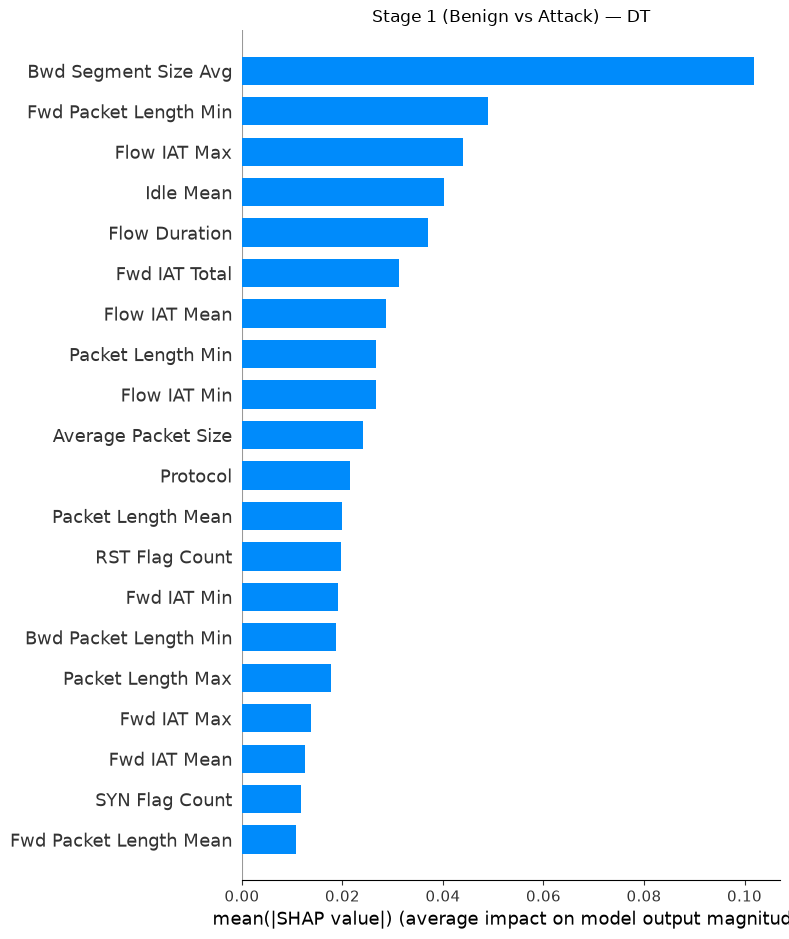

Saved: stage1_DT_global.png

Computing SHAP for Stage 1 XGB...


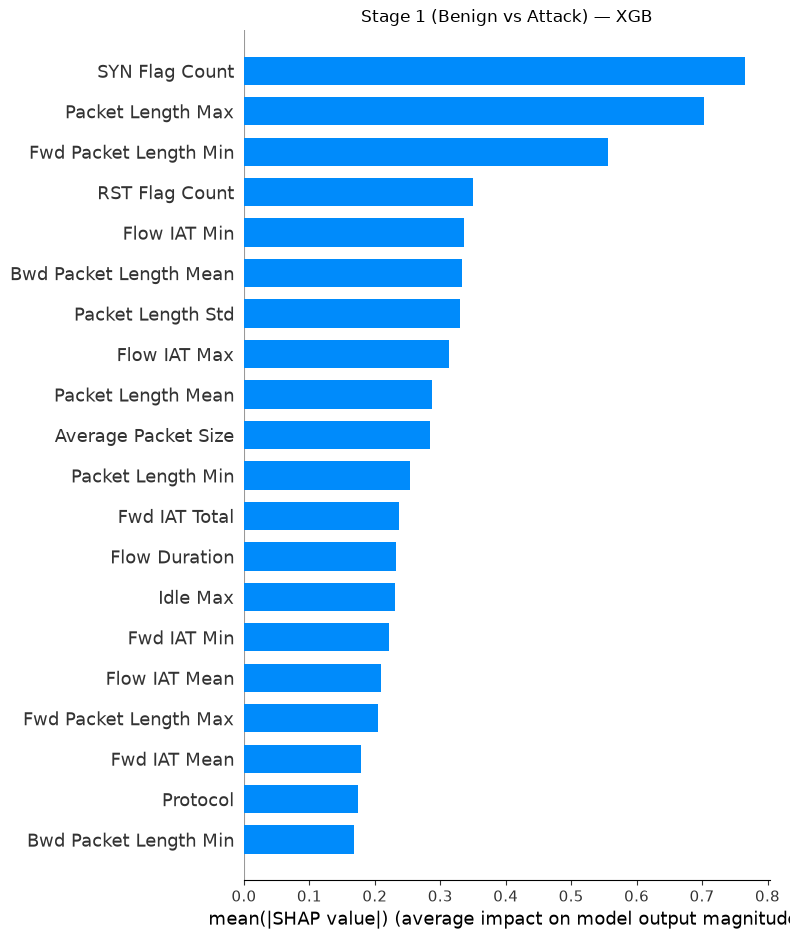

Saved: stage1_XGB_global.png

Computing SHAP for Stage 1 LGBM...


/Users/simrahruq/Documents/GitHub/flat-vs-hierarchical-ml-research/iot-research/lib/python3.12/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


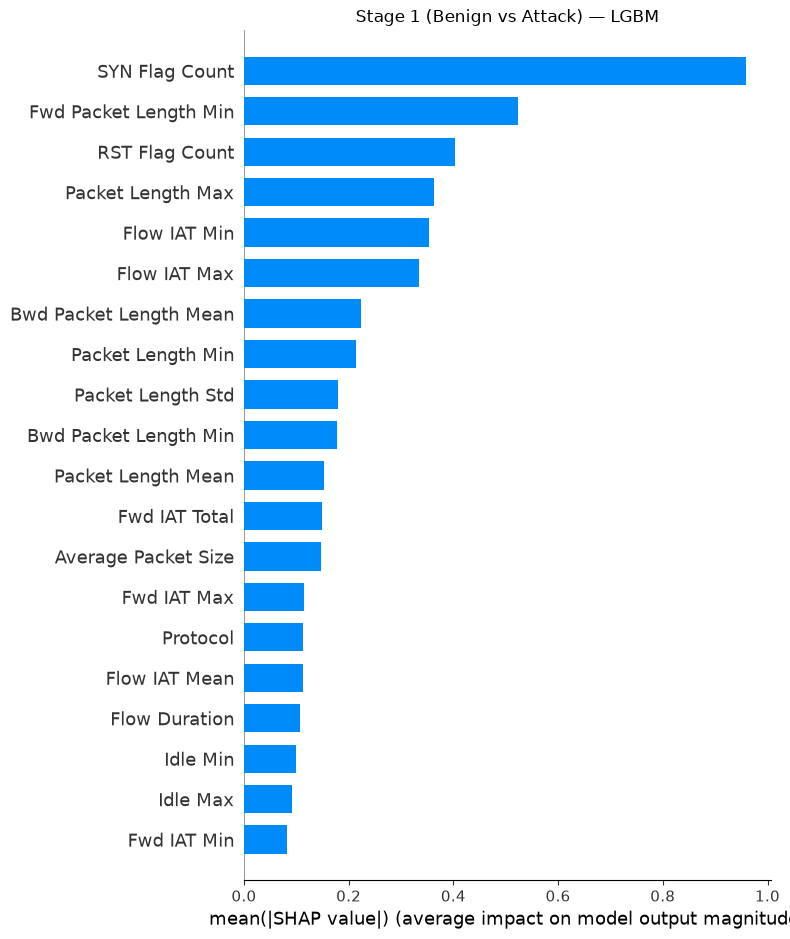

Saved: stage1_LGBM_global.png

Computing SHAP for Stage 1 HGB...


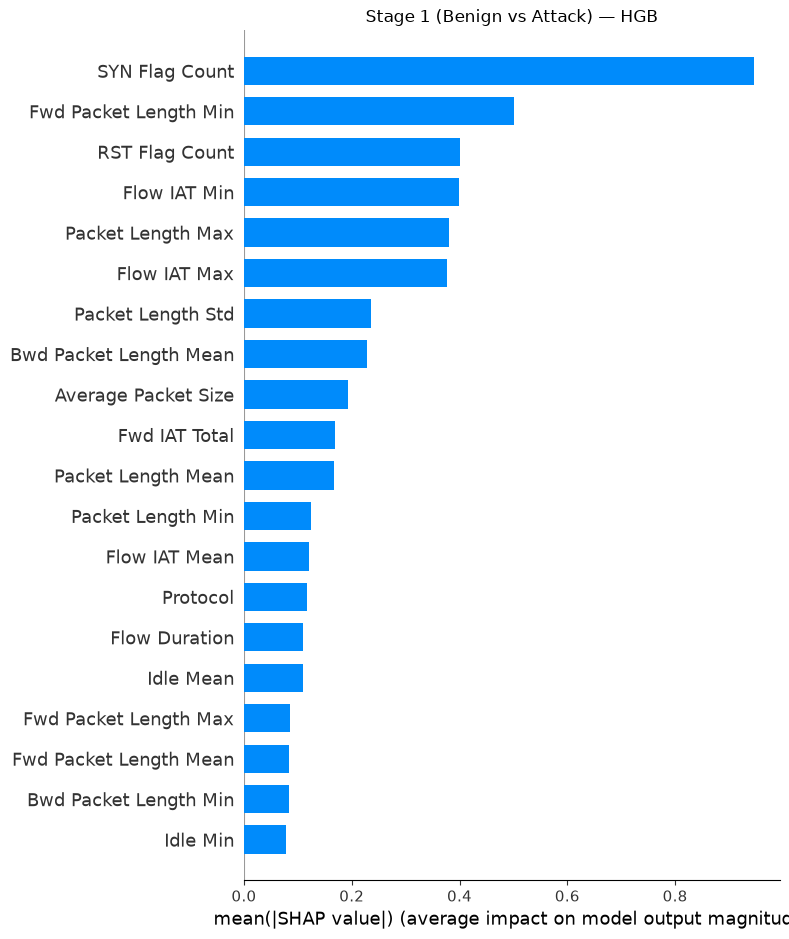

Saved: stage1_HGB_global.png


In [ ]:
# Use smaller sample and faster models only
X_shap_sample = X_test.sample(1000, random_state=42)
y_shap_sample = y_test.loc[X_shap_sample.index]

# Skip RF and ET — too slow
all_models = ['DT', 'XGB', 'LGBM', 'HGB', 'ET', 'RF']

for model_name in all_models:
    print(f"\nComputing SHAP for Stage 1 {model_name}...")
    
    model = joblib.load(f'../results/models/hier_stage1_{model_name}.pkl')
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap_sample)
    
    # Handle both array formats
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        sv_plot = shap_values[:, :, 0]  # Attack class
    elif isinstance(shap_values, list):
        sv_plot = shap_values[0]
    else:
        sv_plot = shap_values
    
    # Global bar plot
    shap.summary_plot(
        sv_plot,
        X_shap_sample,
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )
    plt.title(f"Stage 1 (Benign vs Attack) — {model_name}")
    plt.tight_layout()
    plt.savefig(f'../results/shap/stage1_{model_name}_global.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: stage1_{model_name}_global.png")

Attack samples for Stage 2 SHAP: (698, 30)

Computing SHAP for Stage 2 DT...


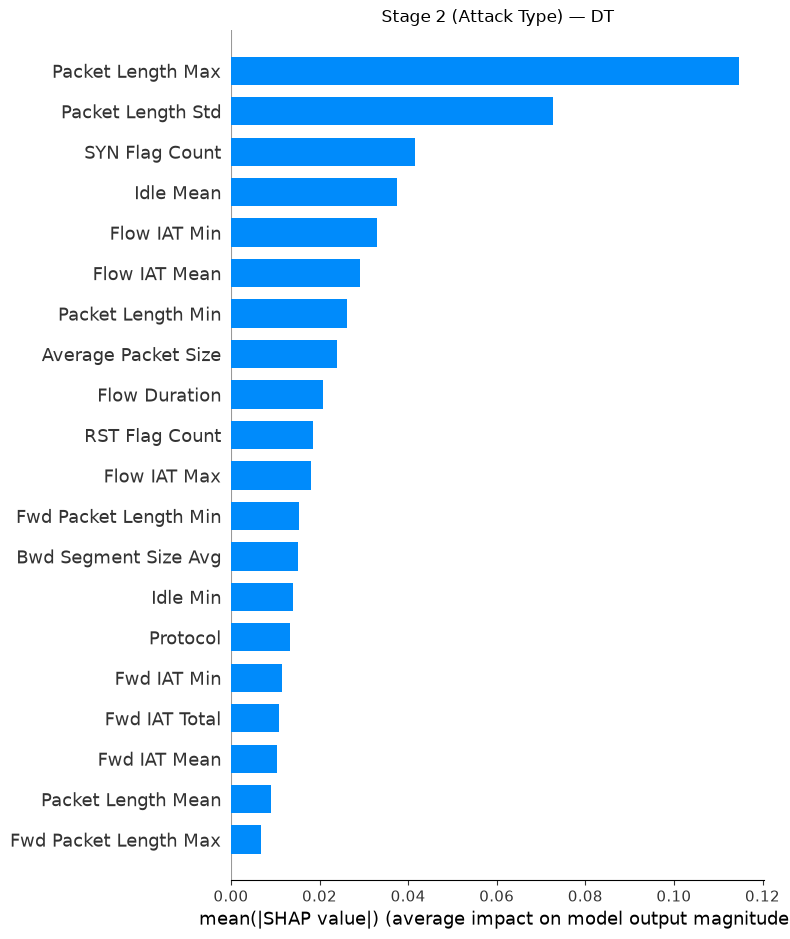

Saved: stage2_DT_global.png

Computing SHAP for Stage 2 XGB...


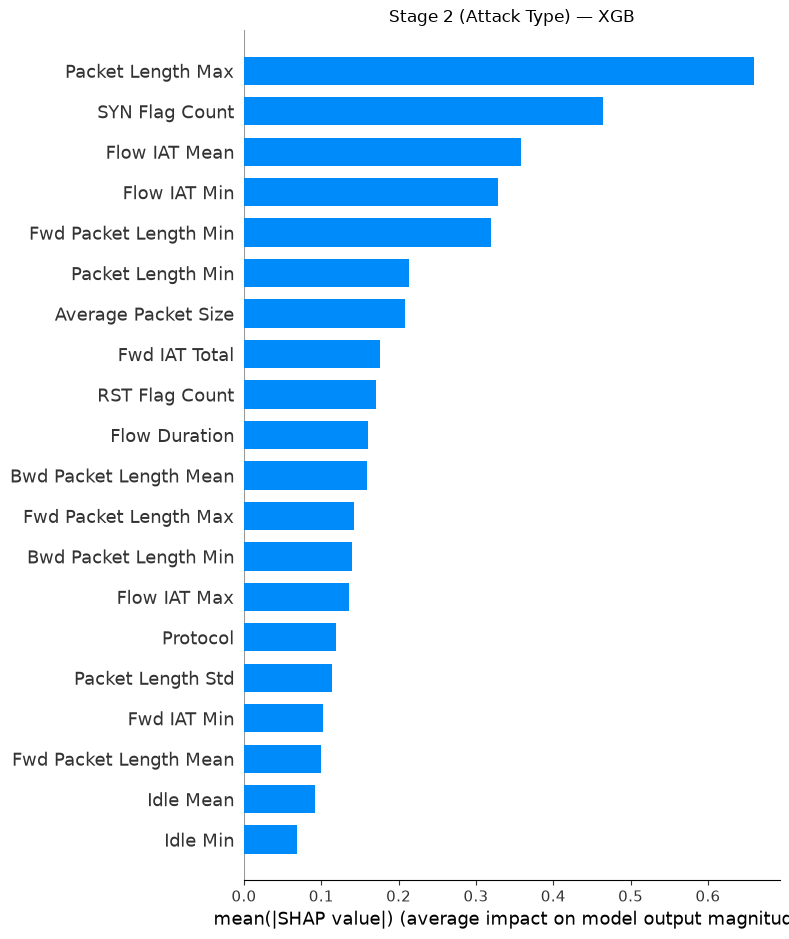

Saved: stage2_XGB_global.png

Computing SHAP for Stage 2 LGBM...


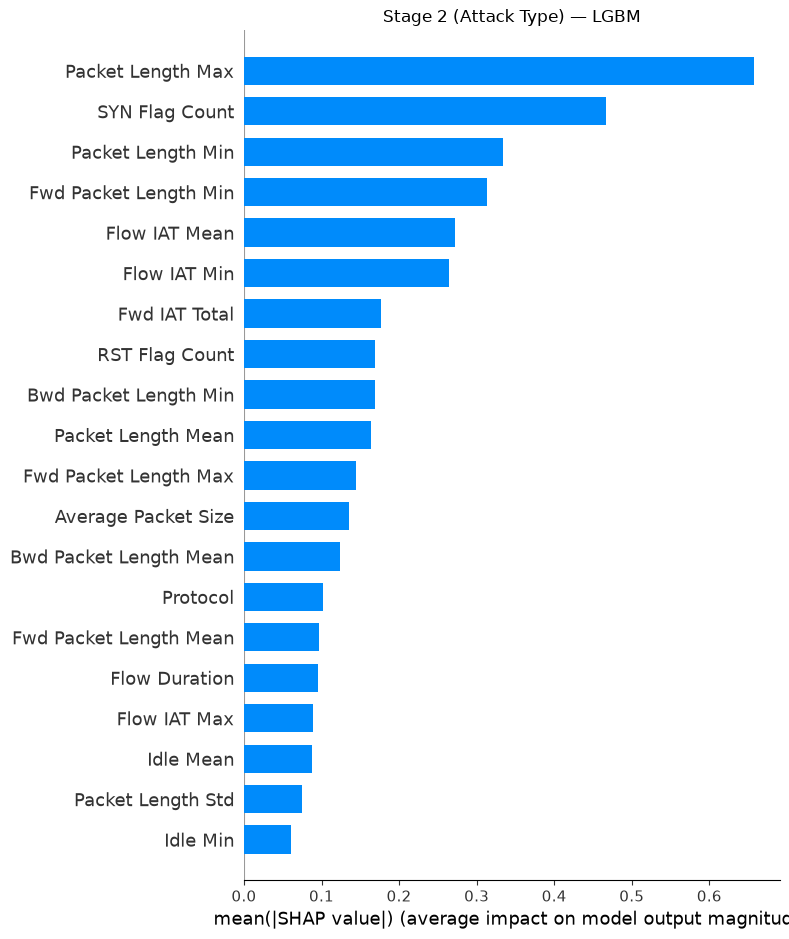

Saved: stage2_LGBM_global.png

Computing SHAP for Stage 2 HGB...


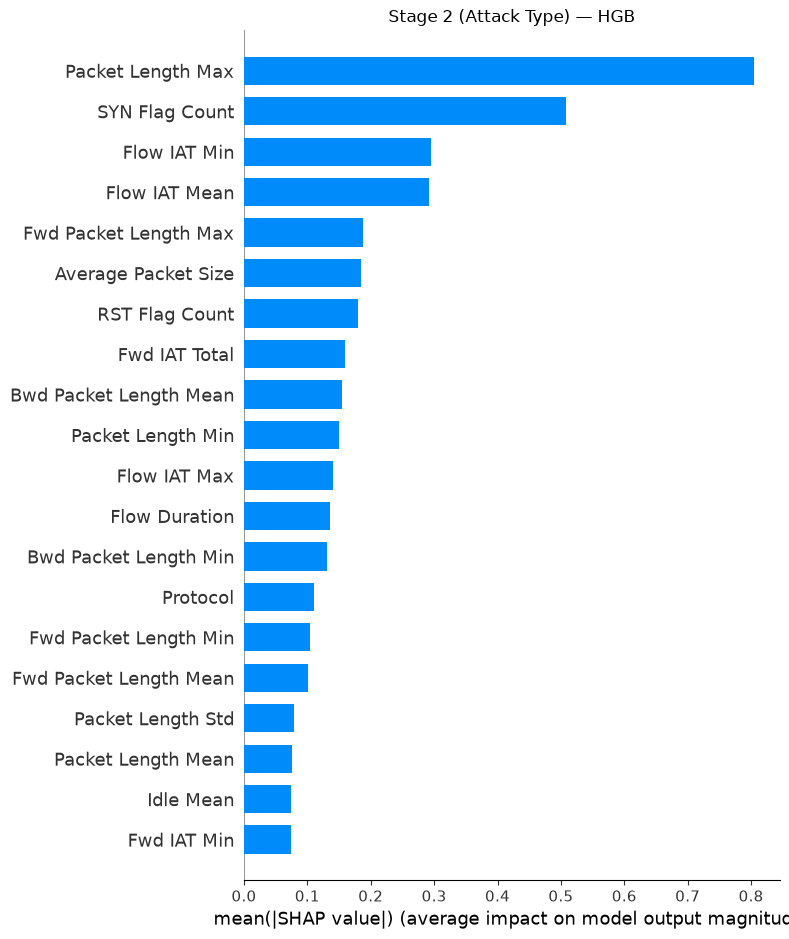

Saved: stage2_HGB_global.png


In [5]:
# Stage 2 — attack rows only
attack_mask = y_shap_sample != 0
X_shap_attacks = X_shap_sample[attack_mask]
print(f"Attack samples for Stage 2 SHAP: {X_shap_attacks.shape}")

for model_name in fast_models:
    print(f"\nComputing SHAP for Stage 2 {model_name}...")
    
    model = joblib.load(f'../results/models/hier_stage2_{model_name}.pkl')
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_shap_attacks)
    
    # Handle output format
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        sv_plot = np.abs(shap_values).mean(axis=2)
    elif isinstance(shap_values, list):
        sv_plot = np.mean([np.abs(sv) for sv in shap_values], axis=0)
    else:
        sv_plot = shap_values

    shap.summary_plot(
        sv_plot,
        X_shap_attacks,
        feature_names=feature_names,
        plot_type="bar",
        show=False
    )
    plt.title(f"Stage 2 (Attack Type) — {model_name}")
    plt.tight_layout()
    plt.savefig(f'../results/shap/stage2_{model_name}_global.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: stage2_{model_name}_global.png")

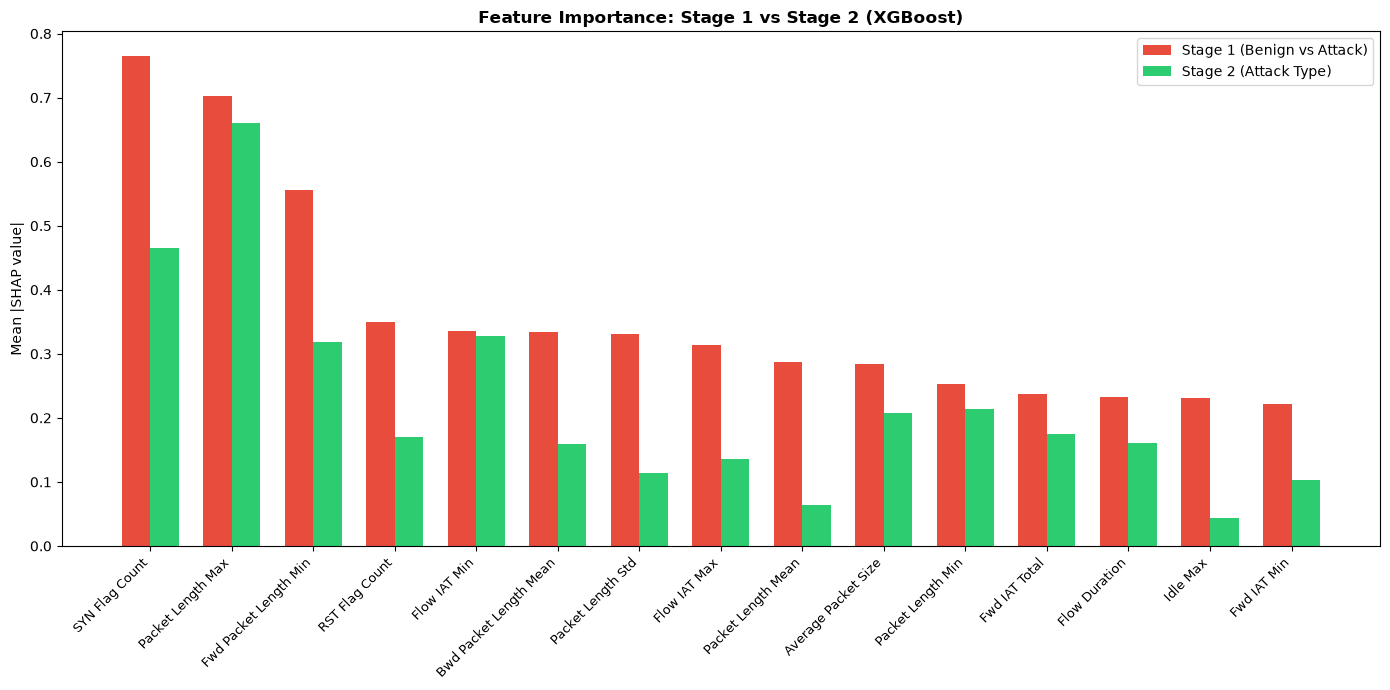

Saved: comparison_stage1_vs_stage2.png


In [6]:
# Load XGB for comparison (consistent and fast)
model_name = 'XGB'

s1_model = joblib.load(f'../results/models/hier_stage1_{model_name}.pkl')
s2_model = joblib.load(f'../results/models/hier_stage2_{model_name}.pkl')

# Stage 1 SHAP
exp_s1 = shap.TreeExplainer(s1_model)
sv_s1  = exp_s1.shap_values(X_shap_sample)

# Stage 2 SHAP  
attack_mask = y_shap_sample != 0
X_shap_attacks = X_shap_sample[attack_mask]
exp_s2 = shap.TreeExplainer(s2_model)
sv_s2  = exp_s2.shap_values(X_shap_attacks)

# Get mean absolute SHAP per feature
if isinstance(sv_s1, np.ndarray) and sv_s1.ndim == 3:
    importance_s1 = np.abs(sv_s1[:, :, 0]).mean(axis=0)
elif isinstance(sv_s1, list):
    importance_s1 = np.abs(sv_s1[0]).mean(axis=0)
else:
    importance_s1 = np.abs(sv_s1).mean(axis=0)

if isinstance(sv_s2, np.ndarray) and sv_s2.ndim == 3:
    importance_s2 = np.abs(sv_s2).mean(axis=2).mean(axis=0)
elif isinstance(sv_s2, list):
    importance_s2 = np.mean([np.abs(sv) for sv in sv_s2], axis=0).mean(axis=0)
else:
    importance_s2 = np.abs(sv_s2).mean(axis=0)

# Build comparison DataFrame — top 15 features by Stage 1 importance
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Stage 1 (Binary)': importance_s1,
    'Stage 2 (Attack Type)': importance_s2,
}).sort_values('Stage 1 (Binary)', ascending=False).head(15)

# Plot
fig, ax = plt.subplots(figsize=(14, 7))
x = np.arange(len(comparison_df))
w = 0.35

ax.bar(x - w/2, comparison_df['Stage 1 (Binary)'],   w,
       label='Stage 1 (Benign vs Attack)', color='#e74c3c')
ax.bar(x + w/2, comparison_df['Stage 2 (Attack Type)'], w,
       label='Stage 2 (Attack Type)',      color='#2ecc71')

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Feature'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean |SHAP value|')
ax.set_title('Feature Importance: Stage 1 vs Stage 2 (XGBoost)', fontweight='bold')
ax.legend()

plt.tight_layout()
plt.savefig('../results/shap/comparison_stage1_vs_stage2.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: comparison_stage1_vs_stage2.png")